In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Utilidades
import warnings
warnings.filterwarnings('ignore')

#GCP
from google.cloud import storage

In [30]:
# Lista los buckets

client = storage.Client()
for bucket in client.list_buckets():
    print(bucket.name)

dataproc-temp-us-central1-595440692498-ydfidu7u
final-bucket-espinal-aguilar
grupo6_scotiabank_bucket6


In [28]:
# Lista todos los archivos 

client = storage.Client()
bucket = client.bucket("final-bucket-espinal-aguilar")

blobs = bucket.list_blobs()

for b in blobs:
    if not b.name.startswith(('.ipynb_checkpoints/', 'google-cloud-dataproc-metainfo/')):
        print(b.name)

bronce/
bronce/raw/
bronce/raw/Flight_delay.csv
notebooks/jupyter/
notebooks/jupyter/script-EDA.ipynb
resources/jb_medallion.py


In [26]:
path = "gs://final-bucket-espinal-aguilar/bronce/raw/Flight_delay.csv"

df = pd.read_csv(path)

In [27]:
df.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


In [31]:
df.shape

(484551, 29)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484551 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DayOfWeek          484551 non-null  int64 
 1   Date               484551 non-null  object
 2   DepTime            484551 non-null  int64 
 3   ArrTime            484551 non-null  int64 
 4   CRSArrTime         484551 non-null  int64 
 5   UniqueCarrier      484551 non-null  object
 6   Airline            484551 non-null  object
 7   FlightNum          484551 non-null  int64 
 8   TailNum            484551 non-null  object
 9   ActualElapsedTime  484551 non-null  int64 
 10  CRSElapsedTime     484551 non-null  int64 
 11  AirTime            484551 non-null  int64 
 12  ArrDelay           484551 non-null  int64 
 13  DepDelay           484551 non-null  int64 
 14  Origin             484551 non-null  object
 15  Org_Airport        483374 non-null  object
 16  Dest               4

In [33]:
# Valores nulos
df.isna().sum().sort_values(ascending=False)

Dest_Airport         1479
Org_Airport          1177
DayOfWeek               0
SecurityDelay           0
NASDelay                0
WeatherDelay            0
CarrierDelay            0
Diverted                0
CancellationCode        0
Cancelled               0
TaxiOut                 0
TaxiIn                  0
Distance                0
Dest                    0
Origin                  0
Date                    0
DepDelay                0
ArrDelay                0
AirTime                 0
CRSElapsedTime          0
ActualElapsedTime       0
TailNum                 0
FlightNum               0
Airline                 0
UniqueCarrier           0
CRSArrTime              0
ArrTime                 0
DepTime                 0
LateAircraftDelay       0
dtype: int64

In [46]:
# Valores nulos por porcentaje
missing_percentage = df.isna().mean().sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

Dest_Airport    0.003052
Org_Airport     0.002429
dtype: float64

In [48]:
# Duplicados
df.duplicated().sum()

2

In [50]:
# Comprobar valores inválidos en fechas 
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
invalid_dates = df['Date'].isna().sum()

In [51]:
invalid_dates

282317

In [ ]:
# erolíneas con pocos vuelos
airline_counts = df['Airline'].value_counts()
airline_counts[airline_counts < 5] 

In [37]:
# Estadísticos básicos de retrasos
delay_cols = [
    "ArrDelay", "CarrierDelay", "WeatherDelay",
    "NASDelay", "SecurityDelay", "LateAircraftDelay"
]
df[delay_cols].describe()

,ArrDelay,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000,484551.000000
mean,60.907764,17.419440,3.153284,13.599421,0.082033,26.653587
std,56.975420,39.417893,19.503657,31.454655,1.884774,40.535994
min,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.000000,2.000000,0.000000,1.000000,0.000000,13.000000
75%,76.000000,19.000000,0.000000,13.000000,0.000000,36.000000
max,1707.000000,1707.000000,1148.000000,1357.000000,392.000000,1254.000000


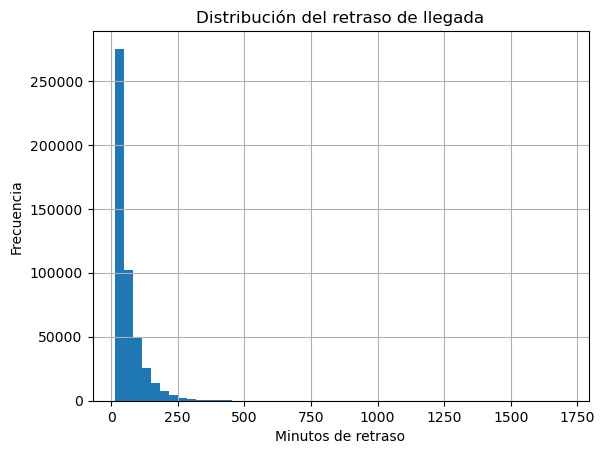

In [38]:
# Distribución del retraso de llegada
plt.figure()
df["ArrDelay"].dropna().hist(bins=50)
plt.title("Distribución del retraso de llegada")
plt.xlabel("Minutos de retraso")
plt.ylabel("Frecuencia")
plt.show()

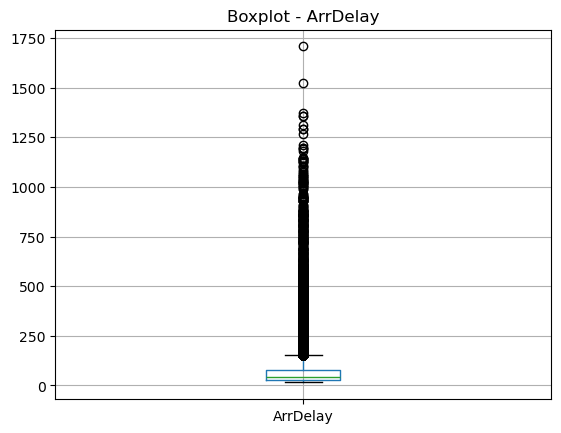

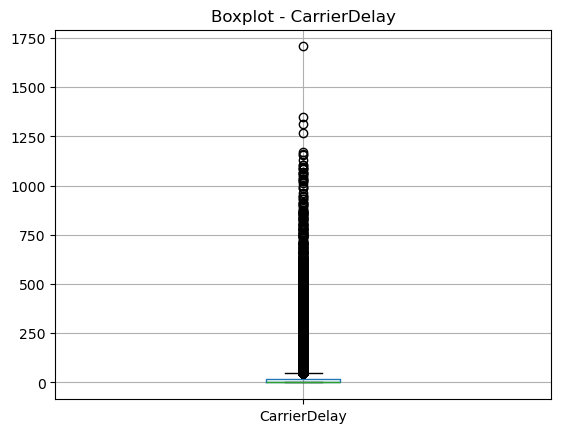

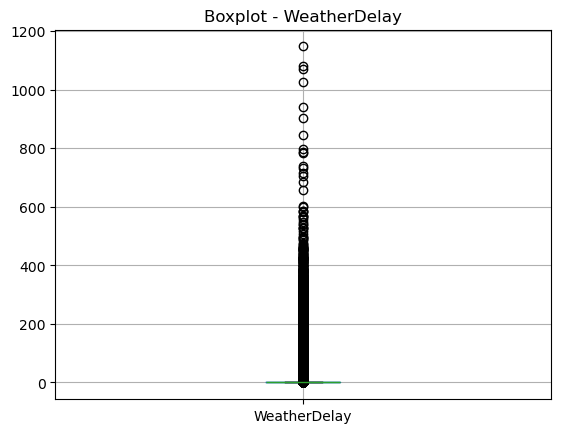

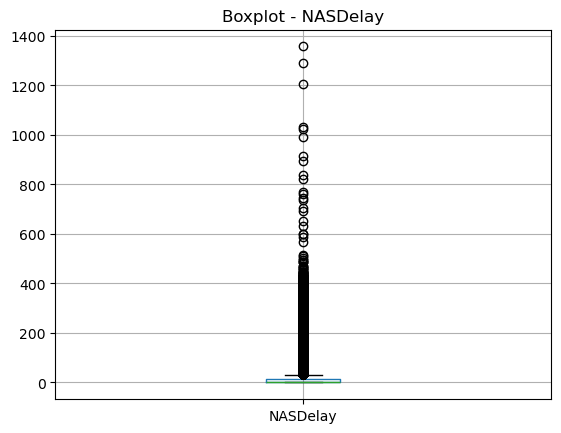

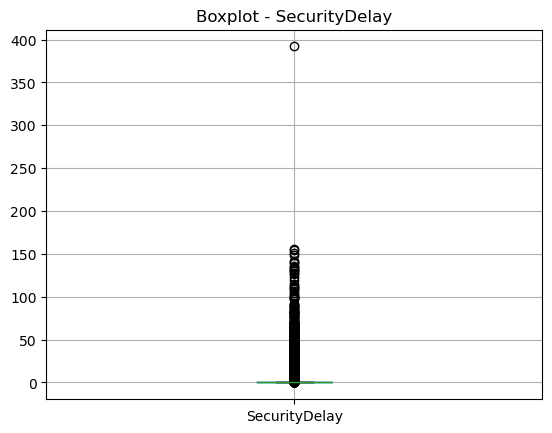

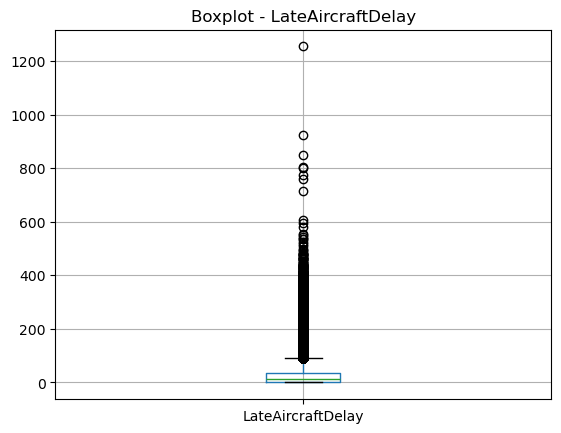

In [49]:
# Valores atípicos en retrasos
for col in delay_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot - {col}")
    plt.show()

In [40]:
# Retrasos promedio por aerolínea
avg_delay_airline = (
    df.groupby("Airline")["ArrDelay"]
    .mean()
    .sort_values(ascending=False)
)

avg_delay_airline.head(10)

Airline
JetBlue Airways                 72.869370
United Air Lines Inc.           69.670539
American Airlines Inc.          65.729621
Skywest Airlines Inc.           65.187659
American Eagle Airlines Inc.    64.277233
Atlantic Southeast Airlines     63.210684
Delta Air Lines Inc.            59.292422
US Airways Inc.                 58.454165
Alaska Airlines Inc.            57.557600
Hawaiian Airlines Inc.          55.658333
Name: ArrDelay, dtype: float64

In [41]:
# Principales causas de retraso (promedio)
df[delay_cols].mean().sort_values(ascending=False)

ArrDelay             60.907764
LateAircraftDelay    26.653587
CarrierDelay         17.419440
NASDelay             13.599421
WeatherDelay          3.153284
SecurityDelay         0.082033
dtype: float64

In [43]:
# Aeropuertos con mayor retraso promedio
avg_delay_origin = (
    df.groupby("Org_Airport")["ArrDelay"]
    .mean()
    .sort_values(ascending=False)
)

avg_delay_origin.head(10)

Org_Airport
Atlantic City International Airport                             187.500000
Eagle County Regional Airport                                   113.590406
Abraham Lincoln Capital Airport                                 111.090909
Capital Region International Airport ( Lansing Capital City)    105.020833
Gunnison-Crested Butte Regional Airport                         103.075949
Abilene Regional Airport                                        100.898089
MBS International Airport                                        94.807692
Sawyer International Airport                                     94.480392
Springfield-Branson National Airport                             91.413646
Cherry Capital Airport                                           90.791304
Name: ArrDelay, dtype: float64